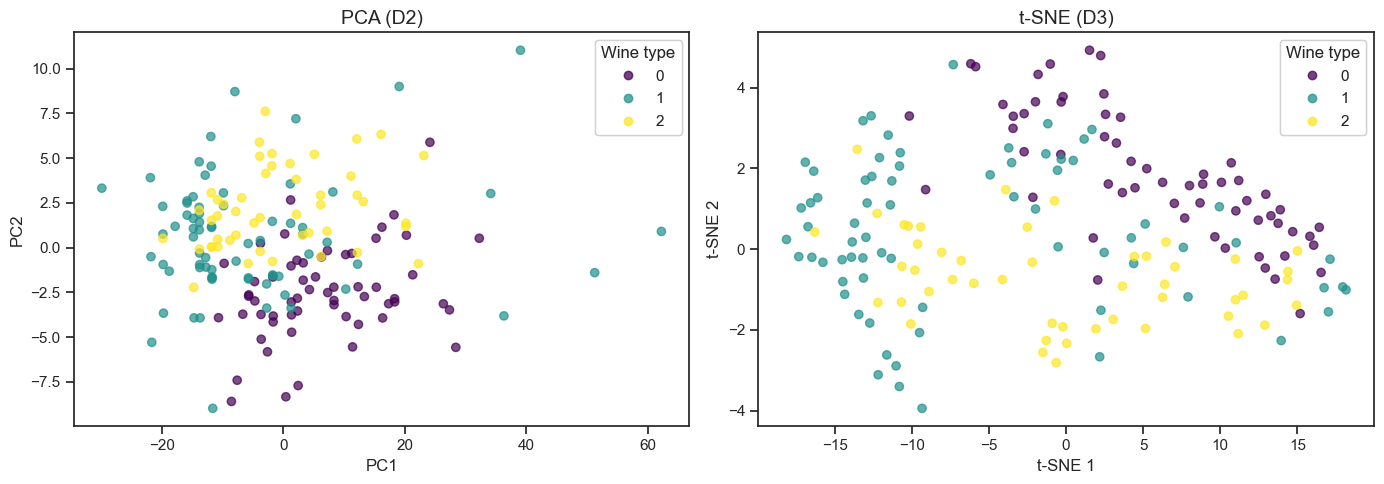

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Загрузка данных
wine = load_wine()
X = wine.data[:, [0,1,2,3,4,5,6]]  # 7 признаков
y = wine.target  # истинные метки для окраски

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PCA
scatter1 = ax1.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis', alpha=0.7)
ax1.set_title('PCA (D2)', fontsize=14)
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
legend1 = ax1.legend(*scatter1.legend_elements(), title="Wine type")
ax1.add_artist(legend1)

# t-SNE
scatter2 = ax2.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap='viridis', alpha=0.7)
ax2.set_title('t-SNE (D3)', fontsize=14)
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')
legend2 = ax2.legend(*scatter2.legend_elements(), title="Wine type")
ax2.add_artist(legend2)

plt.tight_layout()
plt.show()

In [4]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, davies_bouldin_score

# Подготовка данных
datasets = {'D1 (7 features)': X,
            'D2 (PCA)': X_pca,
            'D3 (t-SNE)': X_tsne}

results = []

for name, data in datasets.items():
    # K-means
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(data)
    sil_kmeans = silhouette_score(data, labels_kmeans)
    ari_kmeans = adjusted_rand_score(y, labels_kmeans)
    db_kmeans = davies_bouldin_score(data, labels_kmeans)
    
    # Agglomerative Clustering
    agg = AgglomerativeClustering(n_clusters=3)
    labels_agg = agg.fit_predict(data)
    sil_agg = silhouette_score(data, labels_agg)
    ari_agg = adjusted_rand_score(y, labels_agg)
    db_agg = davies_bouldin_score(data, labels_agg)
    
    # DBSCAN
    dbscan = DBSCAN(eps=0.5 if name != 'D3 (t-SNE)' else 8, min_samples=5)
    # параметры подобраны эмпирически, т.к. масштаб данных разный
    labels_db = dbscan.fit_predict(data)
    n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    
    if n_clusters_db > 1:
        sil_db = silhouette_score(data, labels_db)
        ari_db = adjusted_rand_score(y, labels_db)
        db_db = davies_bouldin_score(data, labels_db)
    else:
        sil_db, ari_db, db_db = -1, -1, np.inf
    
    results.append({
        'Dataset': name,
        'Method': 'K-means',
        'Silhouette': sil_kmeans,
        'ARI': ari_kmeans,
        'Davies-Bouldin': db_kmeans
    })
    results.append({
        'Dataset': name,
        'Method': 'Agglomerative',
        'Silhouette': sil_agg,
        'ARI': ari_agg,
        'Davies-Bouldin': db_agg
    })
    results.append({
        'Dataset': name,
        'Method': 'DBSCAN',
        'Silhouette': sil_db,
        'ARI': ari_db,
        'Davies-Bouldin': db_db
    })

# Результаты в таблицу
df_results = pd.DataFrame(results)
print(df_results.round(4))

           Dataset         Method  Silhouette     ARI  Davies-Bouldin
0  D1 (7 features)        K-means      0.4534  0.1034          0.7078
1  D1 (7 features)  Agglomerative      0.4132  0.1243          0.7599
2  D1 (7 features)         DBSCAN     -1.0000 -1.0000             inf
3         D2 (PCA)        K-means      0.4766  0.1184          0.6727
4         D2 (PCA)  Agglomerative      0.4693  0.1253          0.6862
5         D2 (PCA)         DBSCAN     -1.0000 -1.0000             inf
6       D3 (t-SNE)        K-means      0.5849  0.1297          0.5432
7       D3 (t-SNE)  Agglomerative      0.5815  0.1243          0.5440
8       D3 (t-SNE)         DBSCAN     -1.0000 -1.0000             inf
